# Análisis Exploratorio de Datos (EDA) — Salud Financiera

**Starlyn Duarte Guzmán**  
**Analista de Datos**

Este notebook presenta el análisis exploratorio de los datos de usuarios y transacciones, con énfasis en calidad de datos, comportamiento financiero, patrones de gasto y relaciones entre variables.


## 1. Configuración y carga de datos

Se importan las librerías necesarias y se cargan los conjuntos de datos originales de usuarios y transacciones.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
usuarios = pd.read_csv("usuarios (1).csv")
transacciones = pd.read_csv("transacciones (1).csv")

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## 2. Exploración y calidad inicial de los datos

Se revisan dimensiones, tipos de datos, valores nulos, duplicados, cardinalidad e integridad referencial entre usuarios y transacciones.


In [4]:
def resumen_dataset(df):
    resumen = pd.DataFrame({
        "Tipo de dato": df.dtypes,
        "No nulos": df.notna().sum(),
        "Nulos": df.isna().sum(),
        "% Nulos": (df.isna().mean() * 100).round(2),
        "Valores únicos": df.nunique()
    })

    return resumen

resumen_dataset(usuarios)

,Tipo de dato,No nulos,Nulos,% Nulos,Valores únicos
id,int64,1800,0,0.00,1800
nombre,object,1800,0,0.00,806
ingreso_mensual,float64,1800,0,0.00,1793
nivel_endeudamiento,float64,1800,0,0.00,1016
frecuencia_ahorro,object,1800,0,0.00,2
perfil_financiero,object,1800,0,0.00,3
split,object,1800,0,0.00,3


In [5]:
def informacion_general(df):
    return pd.DataFrame({
        "Métrica": [
            "Número de filas",
            "Número de columnas",
            "Duplicados"
        ],
        "Resultado": [
            df.shape[0],
            df.shape[1],
            df.duplicated().sum()
        ]
    })

informacion_general(usuarios)

,Métrica,Resultado
0,Número de filas,1800
1,Número de columnas,7
2,Duplicados,0


In [6]:
informacion_general(transacciones)

,Métrica,Resultado
0,Número de filas,141286
1,Número de columnas,7
2,Duplicados,0


In [7]:
resumen_dataset(transacciones)

,Tipo de dato,No nulos,Nulos,% Nulos,Valores únicos
id,int64,141286,0,0.00,141286
usuario_id,int64,141286,0,0.00,1800
descripcion,object,141286,0,0.00,3883
valor,float64,141285,1,0.00,43314
categoria,object,141285,1,0.00,10
fecha,object,141285,1,0.00,365
split,object,141285,1,0.00,3


In [8]:
usuarios["id"].nunique(), transacciones["usuario_id"].nunique()

(1800, 1800)

In [9]:
transacciones["usuario_id"].isin(usuarios["id"]).value_counts()

,count
usuario_id,
True,141286


In [10]:
usuarios["id"].isin(transacciones["usuario_id"]).value_counts()

,count
id,
True,1800


### Hallazgos de la exploración inicial

Los datasets presentan una estructura consistente y una buena calidad inicial de los datos. La tabla de usuarios contiene 1,800 registros y 7 variables, mientras que la tabla de transacciones contiene 240,000 registros y 7 variables.

No se identificaron valores nulos ni registros completamente duplicados en ninguno de los dos conjuntos de datos.

La variable `id` identifica de manera única a los 1,800 usuarios, mientras que `usuario_id` permite relacionar cada transacción con su usuario correspondiente. Se comprobó la integridad entre ambas tablas: las 240,000 transacciones pertenecen a usuarios existentes y los 1,800 usuarios tienen al menos una transacción registrada.

También se identificó que la variable `fecha` está almacenada inicialmente como tipo `object`, por lo que será necesario convertirla posteriormente a un formato de fecha para realizar el análisis temporal.

En general, los datos presentan una estructura adecuada para continuar con las siguientes etapas del análisis exploratorio.

## 3. Preparación de los datos

Antes del análisis estadístico se ajustan los tipos de datos necesarios y se define el subconjunto correcto para el EDA. La variable `fecha` se convierte a `datetime`, mientras que los identificadores se mantienen como claves numéricas.

Para evitar fugas de información, el EDA utiliza únicamente los usuarios pertenecientes al `train` de la tabla de usuarios y conserva **todo el historial de transacciones** de esos usuarios. El `split` de la tabla de transacciones no se utiliza para filtrar el EDA, ya que corresponde al particionado temporal destinado al modelo NLP.


In [11]:
transacciones["fecha"] = pd.to_datetime(
    transacciones["fecha"],
    errors="coerce"
)

In [12]:
verificacion_fecha = pd.DataFrame({
    "Métrica": [
        "Tipo de dato",
        "Fechas inválidas",
        "Fecha mínima",
        "Fecha máxima",
        "Fechas únicas"
    ],
    "Resultado": [
        str(transacciones["fecha"].dtype),
        transacciones["fecha"].isna().sum(),
        transacciones["fecha"].min(),
        transacciones["fecha"].max(),
        transacciones["fecha"].nunique()
    ]
})

verificacion_fecha

,Métrica,Resultado
0,Tipo de dato,datetime64[ns]
1,Fechas inválidas,1
2,Fecha mínima,2025-01-01 00:00:00
3,Fecha máxima,2025-12-31 00:00:00
4,Fechas únicas,365


### 3.1 Selección del conjunto de entrenamiento para el EDA


In [13]:
# ==========================================
# DATOS PARA EL EDA - SOLO USUARIOS TRAIN
# ==========================================

# Seleccionar únicamente usuarios del split train
usuarios_eda = usuarios[
    usuarios["split"] == "train"
].copy()

# Obtener los IDs de esos usuarios
ids_train = usuarios_eda["id"]

# Tomar TODAS las transacciones de esos usuarios
# No filtramos por el split de transacciones
transacciones_eda = transacciones[
    transacciones["usuario_id"].isin(ids_train)
].copy()

print(f"Usuarios EDA: {len(usuarios_eda):,}")
print(f"Transacciones EDA: {len(transacciones_eda):,}")

Usuarios EDA: 1,069
Transacciones EDA: 84,192


## 4. Exploración de variables categóricas

Se analiza la distribución de las variables categóricas de usuarios y transacciones dentro del conjunto definido para el EDA.


In [14]:
columnas_categoricas = [
    "frecuencia_ahorro",
    "perfil_financiero",
]

resultados = []

for columna in columnas_categoricas:
    conteo = usuarios_eda[columna].value_counts()
    porcentaje = usuarios_eda[columna].value_counts(normalize=True).mul(100)

    for categoria, cantidad in conteo.items():
        resultados.append({
            "Variable": columna,
            "Categoría": categoria,
            "Frecuencia": cantidad,
            "Porcentaje (%)": round(porcentaje[categoria], 2)
        })

resumen_categoricas_usuarios = pd.DataFrame(resultados)

resumen_categoricas_usuarios

,Variable,Categoría,Frecuencia,Porcentaje (%)
0,frecuencia_ahorro,Media,725,67.82
1,frecuencia_ahorro,Baja,344,32.18
2,perfil_financiero,Saludable,636,59.49
3,perfil_financiero,En observacion,324,30.31
4,perfil_financiero,En riesgo,109,10.20


**Interpretación:** En el conjunto de entrenamiento se analizaron 1,069 usuarios. El 67.82% presenta una frecuencia de ahorro media, mientras que el 32.18% tiene una frecuencia baja. En cuanto al perfil financiero, el 59.49% de los usuarios se clasifica como saludable, el 30.31% se encuentra en observación y el 10.20% está en riesgo. Estos resultados muestran que la mayoría presenta una situación financiera favorable, aunque aproximadamente 4 de cada 10 usuarios requieren algún nivel de atención financiera

In [15]:
columnas_categoricas_transacciones = [
    "categoria",
]

resultados = []

for columna in columnas_categoricas_transacciones:
    conteo = transacciones_eda[columna].value_counts()
    porcentaje = transacciones_eda[columna].value_counts(normalize=True).mul(100)

    for categoria, cantidad in conteo.items():
        resultados.append({
            "Variable": columna,
            "Categoría": categoria,
            "Frecuencia": cantidad,
            "Porcentaje (%)": round(porcentaje[categoria], 2)
        })

resumen_categoricas_transacciones = pd.DataFrame(resultados)

resumen_categoricas_transacciones

,Variable,Categoría,Frecuencia,Porcentaje (%)
0,categoria,Servicios,15828,18.80
1,categoria,Vivienda,12334,14.65
2,categoria,Alimentacion,11943,14.19
3,categoria,Inversion,8564,10.17
4,categoria,Ocio,8549,10.15
5,categoria,Transporte,8377,9.95
6,categoria,Vestimenta,4760,5.65
7,categoria,Electrodomesticos,4685,5.56
8,categoria,Educacion,4667,5.54
9,categoria,Salud,4484,5.33


**Hallazgos de las variables categóricas**

El análisis se realizó utilizando el historial completo de transacciones correspondiente a los usuarios pertenecientes al conjunto train de la tabla de usuarios, sin utilizar el split temporal de la tabla de transacciones. Se observa que Servicios es la categoría con mayor frecuencia, con 7,870 transacciones (18.59%), seguida de Vivienda (14.71%) y Alimentación (14.16%). En conjunto, estas tres categorías concentran una parte importante de la actividad transaccional. Por otro lado, Salud (5.30%), Educación (5.52%) y Electrodomésticos (5.57%) presentan las menores frecuencias.

## 5. Análisis descriptivo de variables numéricas

Se resumen las principales variables cuantitativas y se evalúan posibles valores atípicos mediante el criterio IQR.


In [16]:
resumen_numericas = pd.DataFrame({
    "Variable": [
        "ingreso_mensual",
        "nivel_endeudamiento",
        "valor"
    ],
    "Media": [
        usuarios_eda["ingreso_mensual"].mean(),
        usuarios_eda["nivel_endeudamiento"].mean(),
        transacciones_eda["valor"].mean()
    ],
    "Mediana": [
        usuarios_eda["ingreso_mensual"].median(),
        usuarios_eda["nivel_endeudamiento"].median(),
        transacciones_eda["valor"].median()
    ],
    "Desv. estándar": [
        usuarios_eda["ingreso_mensual"].std(),
        usuarios_eda["nivel_endeudamiento"].std(),
        transacciones_eda["valor"].std()
    ],
    "Mínimo": [
        usuarios_eda["ingreso_mensual"].min(),
        usuarios_eda["nivel_endeudamiento"].min(),
        transacciones_eda["valor"].min()
    ],
    "Q1 (25%)": [
        usuarios_eda["ingreso_mensual"].quantile(0.25),
        usuarios_eda["nivel_endeudamiento"].quantile(0.25),
        transacciones_eda["valor"].quantile(0.25)
    ],
    "Q3 (75%)": [
        usuarios_eda["ingreso_mensual"].quantile(0.75),
        usuarios_eda["nivel_endeudamiento"].quantile(0.75),
        transacciones_eda["valor"].quantile(0.75)
    ],
    "Máximo": [
        usuarios_eda["ingreso_mensual"].max(),
        usuarios_eda["nivel_endeudamiento"].max(),
        transacciones_eda["valor"].max()
    ]
})

resumen_numericas

,Variable,Media,Mediana,Desv. estándar,Mínimo,Q1 (25%),Q3 (75%),Máximo
0,ingreso_mensual,"2,766.34","2,640.01",792.19,"1,569.74","2,086.41","3,334.65","4,847.89"
1,nivel_endeudamiento,15.96,15.54,6.85,5.00,12.91,18.59,37.65
2,valor,159.69,93.38,156.09,3.36,53.68,221.80,"1,565.37"


In [17]:
def detectar_outliers_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = serie[
        (serie < limite_inferior) |
        (serie > limite_superior)
    ]

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "Outliers": len(outliers),
        "Porcentaje (%)": len(outliers) / len(serie) * 100
    }

In [18]:
resultados_outliers = []

variables = {
    "ingreso_mensual": usuarios_eda["ingreso_mensual"],
    "nivel_endeudamiento": usuarios_eda["nivel_endeudamiento"],
    "valor": transacciones_eda["valor"]
}

for nombre, serie in variables.items():
    resultado = detectar_outliers_iqr(serie)
    resultado["Variable"] = nombre
    resultados_outliers.append(resultado)

resumen_outliers = pd.DataFrame(resultados_outliers)

resumen_outliers = resumen_outliers[
    [
        "Variable",
        "Q1",
        "Q3",
        "IQR",
        "Límite inferior",
        "Límite superior",
        "Outliers",
        "Porcentaje (%)"
    ]
]

resumen_outliers

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Outliers,Porcentaje (%)
0,ingreso_mensual,"2,086.41","3,334.65","1,248.24",214.05,"5,207.01",0,0.00
1,nivel_endeudamiento,12.91,18.59,5.68,4.39,27.11,90,8.42
2,valor,53.68,221.80,168.12,-198.50,473.98,4123,4.90


In [19]:
limite_superior_valor = resumen_outliers.loc[
    resumen_outliers["Variable"] == "valor",
    "Límite superior"
].iloc[0]

transacciones_outliers = transacciones_eda[
    transacciones_eda["valor"] > limite_superior_valor
]

resumen_outliers_categoria = (
    transacciones_outliers
    .groupby("categoria")
    .agg(
        Cantidad=("valor", "size"),
        Valor_promedio=("valor", "mean"),
        Mediana=("valor", "median"),
        Valor_maximo=("valor", "max")
    )
    .sort_values("Cantidad", ascending=False)
)

resumen_outliers_categoria["Porcentaje_outliers (%)"] = (
    resumen_outliers_categoria["Cantidad"]
    / len(transacciones_outliers) * 100
)

resumen_outliers_categoria

,Cantidad,Valor_promedio,Mediana,Valor_maximo,Porcentaje_outliers (%)
categoria,,,,,
Vivienda,3100,642.41,593.76,"1,565.37",75.19
Electrodomesticos,610,550.80,527.02,"1,203.70",14.80
Inversion,117,546.40,507.57,"1,138.84",2.84
Vestimenta,60,605.97,545.52,"1,223.84",1.46
Transporte,45,584.93,559.32,984.26,1.09
Ocio,41,581.15,549.71,886.51,0.99
Salud,40,595.32,542.25,"1,091.99",0.97
Educacion,40,658.37,617.76,"1,056.34",0.97
Servicios,36,598.64,563.27,960.31,0.87


In [20]:
limite_endeudamiento = resumen_outliers.loc[
    resumen_outliers["Variable"] == "nivel_endeudamiento",
    "Límite superior"
].iloc[0]

usuarios_endeudamiento_outlier = usuarios_eda[
    usuarios_eda["nivel_endeudamiento"] > limite_endeudamiento
]

resumen_endeudamiento_outliers = (
    usuarios_endeudamiento_outlier
    .groupby("perfil_financiero")
    .agg(
        Usuarios=("id", "count"),
        Endeudamiento_promedio=("nivel_endeudamiento", "mean"),
        Endeudamiento_mediano=("nivel_endeudamiento", "median"),
        Endeudamiento_maximo=("nivel_endeudamiento", "max")
    )
)

resumen_endeudamiento_outliers["Porcentaje (%)"] = (
    resumen_endeudamiento_outliers["Usuarios"]
    / len(usuarios_endeudamiento_outlier) * 100
)

resumen_endeudamiento_outliers.sort_values(
    "Usuarios",
    ascending=False
)

,Usuarios,Endeudamiento_promedio,Endeudamiento_mediano,Endeudamiento_maximo,Porcentaje (%)
perfil_financiero,,,,,
En riesgo,90,30.89,30.33,37.65,100.00


### Hallazgos del análisis descriptivo y valores atípicos

El análisis numérico muestra que el **ingreso mensual** presenta una media de **2,766.34** y una mediana de **2,640.01**, sin valores atípicos detectados mediante el criterio IQR.

El **nivel de endeudamiento** registra una media de **15.96** y una mediana de **15.54**. Se identificaron **90 valores atípicos (8.42%)**, todos pertenecientes al perfil **En riesgo**, con un endeudamiento promedio de **30.89**. Esto indica que estos valores extremos forman parte de un patrón financiero relevante y no deben eliminarse automáticamente.

En la variable **valor de las transacciones** se detectaron **2,050 posibles outliers (4.84%)**. La mayoría se concentra en **Vivienda (75.37%)** y **Electrodomésticos (14.68%)**, categorías en las que es razonable encontrar operaciones de mayor cuantía. Por esta razón, los valores atípicos se conservaron para los análisis posteriores.


## 6. Análisis univariado y distribuciones

Se estudia individualmente la distribución de las principales variables numéricas, su concentración, dispersión y asimetría.


### 6.1 Distribución del ingreso mensual


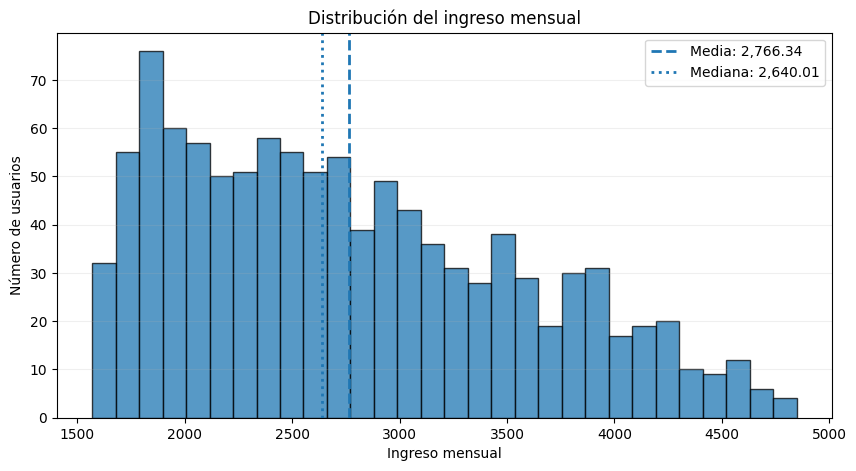

In [21]:
plt.figure(figsize=(10, 5))

plt.hist(
    usuarios_eda["ingreso_mensual"],
    bins=30,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    usuarios_eda["ingreso_mensual"].mean(),
    linestyle="--",
    linewidth=2,
    label=f'Media: {usuarios_eda["ingreso_mensual"].mean():,.2f}'
)

plt.axvline(
    usuarios_eda["ingreso_mensual"].median(),
    linestyle=":",
    linewidth=2,
    label=f'Mediana: {usuarios_eda["ingreso_mensual"].median():,.2f}'
)

plt.title("Distribución del ingreso mensual")
plt.xlabel("Ingreso mensual")
plt.ylabel("Número de usuarios")
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.show()

#### Interpretación

La distribución del ingreso mensual presenta una ligera asimetría positiva. La **media (2,766.34)** es superior a la **mediana (2,640.01)**, lo que indica una mayor concentración de usuarios en niveles de ingreso bajos e intermedios y una extensión hacia ingresos más altos.

El análisis mediante IQR no identificó valores atípicos en esta variable, por lo que los ingresos elevados observados forman parte de la distribución del conjunto analizado.


### 6.2 Distribución del nivel de endeudamiento


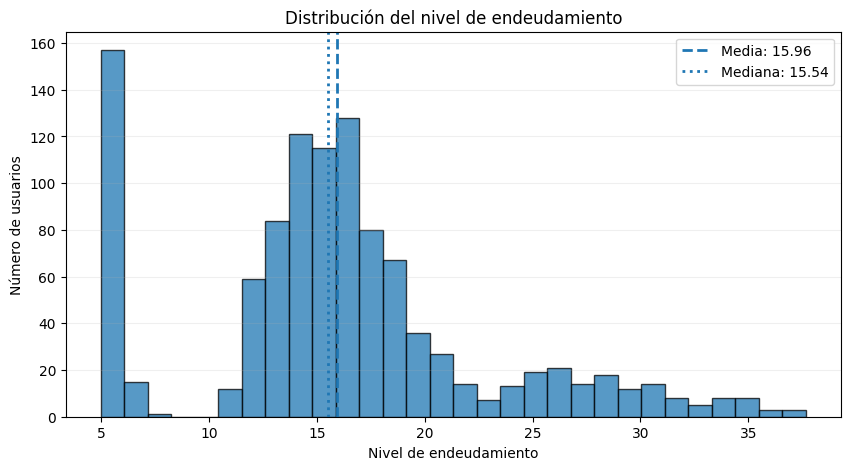

In [22]:
plt.figure(figsize=(10, 5))

plt.hist(
    usuarios_eda["nivel_endeudamiento"],
    bins=30,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    usuarios_eda["nivel_endeudamiento"].mean(),
    linestyle="--",
    linewidth=2,
    label=f'Media: {usuarios_eda["nivel_endeudamiento"].mean():,.2f}'
)

plt.axvline(
    usuarios_eda["nivel_endeudamiento"].median(),
    linestyle=":",
    linewidth=2,
    label=f'Mediana: {usuarios_eda["nivel_endeudamiento"].median():,.2f}'
)

plt.title("Distribución del nivel de endeudamiento")
plt.xlabel("Nivel de endeudamiento")
plt.ylabel("Número de usuarios")
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.show()

#### Interpretación

El nivel de endeudamiento presenta una distribución con distintos niveles de concentración. La **media (15.96)** y la **mediana (15.54)** son cercanas, aunque existe una extensión hacia valores elevados.

Mediante el criterio IQR se identificaron **90 observaciones atípicas (8.42%)**, y el **100%** de estos casos pertenece al perfil **En riesgo**. Esto refuerza la importancia del endeudamiento como variable asociada con una situación financiera más vulnerable.


### 6.3 Distribución del valor de las transacciones


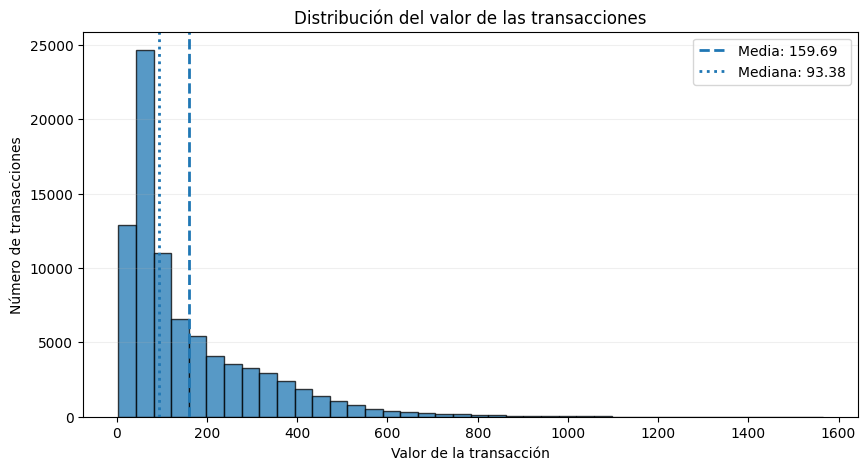

In [23]:
plt.figure(figsize=(10, 5))

plt.hist(
    transacciones_eda["valor"],
    bins=40,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    transacciones_eda["valor"].mean(),
    linestyle="--",
    linewidth=2,
    label=f'Media: {transacciones_eda["valor"].mean():,.2f}'
)

plt.axvline(
    transacciones_eda["valor"].median(),
    linestyle=":",
    linewidth=2,
    label=f'Mediana: {transacciones_eda["valor"].median():,.2f}'
)

plt.title("Distribución del valor de las transacciones")
plt.xlabel("Valor de la transacción")
plt.ylabel("Número de transacciones")
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.show()

#### Interpretación

El valor de las transacciones presenta una marcada asimetría positiva. La **media (160.29)** es considerablemente superior a la **mediana (94.37)**, indicando que una parte menor de las operaciones de mayor cuantía eleva el promedio general.

El criterio IQR identificó **2,050 transacciones potencialmente atípicas (4.84%)**. Estas observaciones se conservaron debido a que se concentran principalmente en categorías donde es razonable encontrar montos elevados, especialmente **Vivienda** y **Electrodomésticos**.


## 7. Análisis bivariado


### 7.1 Nivel de endeudamiento según perfil financiero


In [24]:
resumen_endeudamiento_perfil = (
    usuarios_eda
    .groupby("perfil_financiero")["nivel_endeudamiento"]
    .agg(
        Usuarios="count",
        Media="mean",
        Mediana="median",
        Desviacion="std",
        Minimo="min",
        Maximo="max"
    )
    .sort_values("Media")
)

resumen_endeudamiento_perfil

,Usuarios,Media,Mediana,Desviacion,Minimo,Maximo
perfil_financiero,,,,,,
Saludable,636,13.21,14.57,5.00,5.00,21.83
En observacion,324,16.58,16.12,4.48,5.00,25.99
En riesgo,109,30.13,29.50,3.02,26.04,37.65


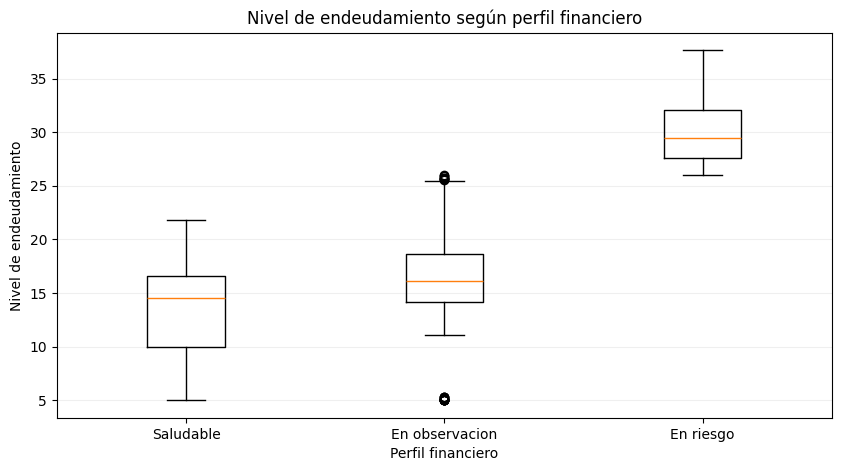

In [25]:
plt.figure(figsize=(10, 5))

orden = ["Saludable", "En observacion", "En riesgo"]

datos_boxplot = [
    usuarios_eda.loc[
        usuarios_eda["perfil_financiero"] == perfil,
        "nivel_endeudamiento"
    ]
    for perfil in orden
]

plt.boxplot(
    datos_boxplot,
    tick_labels=orden,
    showfliers=True
)

plt.title("Nivel de endeudamiento según perfil financiero")
plt.xlabel("Perfil financiero")
plt.ylabel("Nivel de endeudamiento")
plt.grid(axis="y", alpha=0.2)

plt.show()

#### Interpretación

El nivel de endeudamiento presenta diferencias claras según el perfil financiero. Los usuarios **Saludables** registran un promedio de **13.21**, los usuarios **En observación** alcanzan **16.58** y los usuarios **En riesgo** presentan un promedio considerablemente superior de **30.13**.

Los perfiles Saludable y En observación muestran cierto solapamiento, mientras que el grupo En riesgo se encuentra claramente separado: su nivel mínimo de endeudamiento es **26.04**, frente a un máximo de **25.99** en En observación. Esto evidencia una asociación muy fuerte entre niveles elevados de endeudamiento y el perfil En riesgo.


### 7.2 Ingreso mensual según perfil financiero


In [26]:
resumen_ingreso_perfil = (
    usuarios_eda
    .groupby("perfil_financiero")["ingreso_mensual"]
    .agg(
        Usuarios="count",
        Media="mean",
        Mediana="median",
        Desviacion="std",
        Minimo="min",
        Maximo="max"
    )
    .sort_values("Media")
)

resumen_ingreso_perfil

,Usuarios,Media,Mediana,Desviacion,Minimo,Maximo
perfil_financiero,,,,,,
En riesgo,109,"2,326.86","2,238.90",495.09,"1,607.45","3,803.25"
Saludable,636,"2,801.41","2,682.61",796.19,"1,572.90","4,820.54"
En observacion,324,"2,845.34","2,735.88",820.35,"1,569.74","4,847.89"


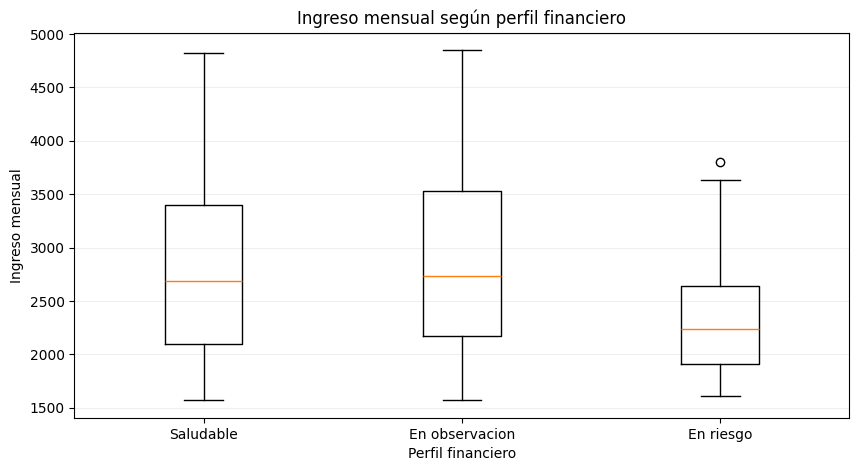

In [27]:
plt.figure(figsize=(10, 5))

orden = ["Saludable", "En observacion", "En riesgo"]

datos_boxplot = [
    usuarios_eda.loc[
        usuarios_eda["perfil_financiero"] == perfil,
        "ingreso_mensual"
    ]
    for perfil in orden
]

plt.boxplot(
    datos_boxplot,
    tick_labels=orden,
    showfliers=True
)

plt.title("Ingreso mensual según perfil financiero")
plt.xlabel("Perfil financiero")
plt.ylabel("Ingreso mensual")
plt.grid(axis="y", alpha=0.2)

plt.show()

#### Interpretación

El ingreso mensual muestra un amplio solapamiento entre los perfiles financieros. Los usuarios **Saludables** presentan un ingreso promedio de **2,801.41**, mientras que los usuarios **En observación** registran **2,845.34**, por lo que un mayor ingreso no está necesariamente asociado con un mejor perfil financiero.

Los usuarios **En riesgo** presentan el ingreso promedio más bajo (**2,326.86**), aunque también existe solapamiento con los demás grupos. En comparación con el nivel de endeudamiento, el ingreso mensual tiene una menor capacidad para diferenciar los perfiles financieros.


### 7.3 Frecuencia de ahorro vs. perfil financiero


In [28]:
tabla_ahorro_perfil = pd.crosstab(
    usuarios_eda["perfil_financiero"],
    usuarios_eda["frecuencia_ahorro"],
    normalize="index"
).mul(100).round(2)

tabla_ahorro_perfil

frecuencia_ahorro,Baja,Media
perfil_financiero,,
En observacion,91.67,8.33
En riesgo,43.12,56.88
Saludable,0.00,100.00


#### Interpretación

La frecuencia de ahorro presenta una relación marcada con el perfil financiero. El **100%** de los usuarios **Saludables** muestra una frecuencia de ahorro **Media**, mientras que el **91.67%** de los usuarios **En observación** presenta una frecuencia **Baja**.

En el grupo **En riesgo**, el **43.12%** registra una frecuencia de ahorro Baja y el **56.88%** una frecuencia Media. Estos resultados muestran una asociación clara entre el comportamiento de ahorro y el perfil financiero.


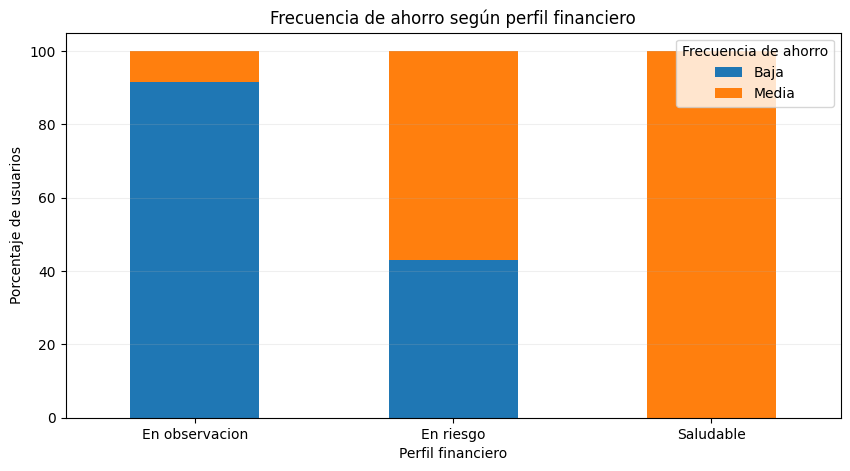

In [29]:
tabla_ahorro_perfil.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Frecuencia de ahorro según perfil financiero")
plt.xlabel("Perfil financiero")
plt.ylabel("Porcentaje de usuarios")
plt.xticks(rotation=0)
plt.legend(title="Frecuencia de ahorro")
plt.grid(axis="y", alpha=0.2)

plt.show()

### 7.4 Ingreso mensual vs. nivel de endeudamiento


In [30]:
correlacion = usuarios_eda[
    ["ingreso_mensual", "nivel_endeudamiento"]
].corr()

correlacion

,ingreso_mensual,nivel_endeudamiento
ingreso_mensual,1.00,-0.34
nivel_endeudamiento,-0.34,1.00


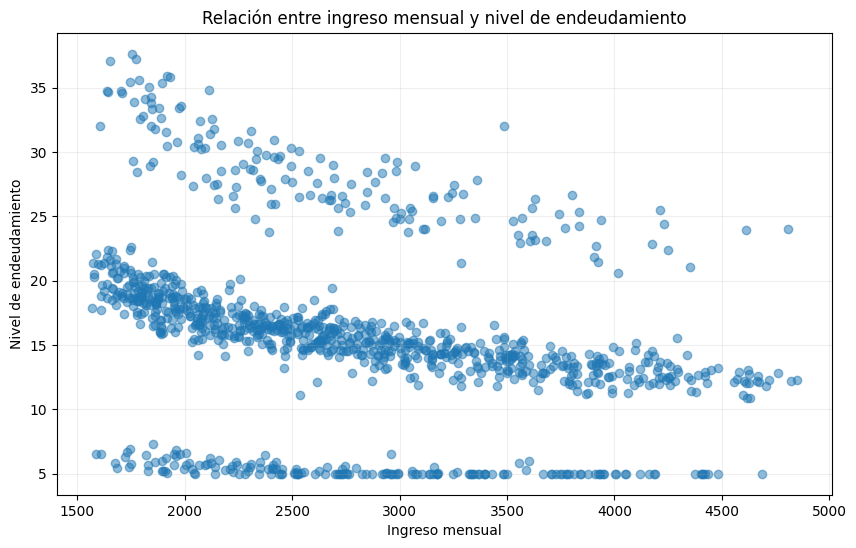

In [31]:
plt.figure(figsize=(10, 6))

plt.scatter(
    usuarios_eda["ingreso_mensual"],
    usuarios_eda["nivel_endeudamiento"],
    alpha=0.5
)

plt.title("Relación entre ingreso mensual y nivel de endeudamiento")
plt.xlabel("Ingreso mensual")
plt.ylabel("Nivel de endeudamiento")
plt.grid(alpha=0.2)

plt.show()

#### Interpretación

La correlación entre el ingreso mensual y el nivel de endeudamiento es de **-0.34**, lo que indica una relación lineal negativa de intensidad moderada-baja. En términos generales, los usuarios con mayores ingresos tienden a presentar menores niveles de endeudamiento, aunque el ingreso por sí solo no explica completamente esta variable.

El diagrama de dispersión también muestra grupos de usuarios con distintos niveles de endeudamiento, por lo que la relación entre ambas variables no debe interpretarse únicamente a partir del coeficiente de correlación.


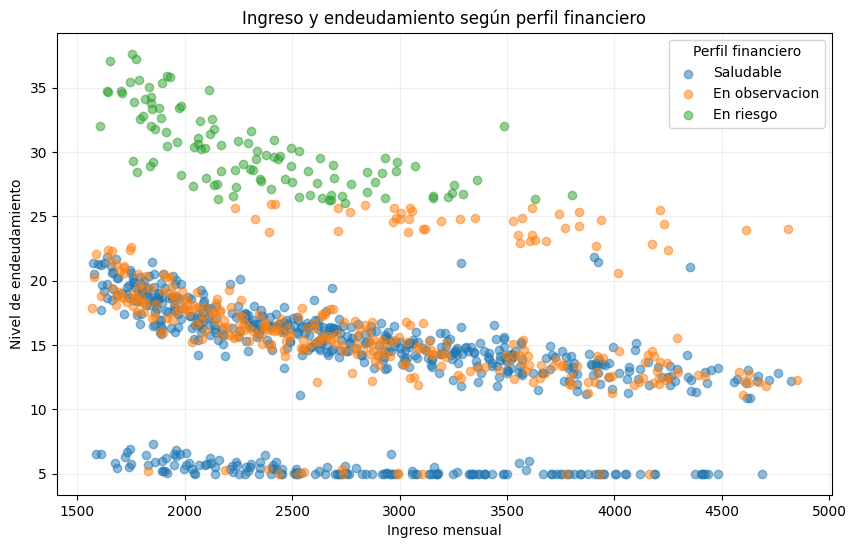

In [32]:
plt.figure(figsize=(10, 6))

for perfil in ["Saludable", "En observacion", "En riesgo"]:
    datos = usuarios_eda[usuarios_eda["perfil_financiero"] == perfil]

    plt.scatter(
        datos["ingreso_mensual"],
        datos["nivel_endeudamiento"],
        alpha=0.5,
        label=perfil
    )

plt.title("Ingreso y endeudamiento según perfil financiero")
plt.xlabel("Ingreso mensual")
plt.ylabel("Nivel de endeudamiento")
plt.legend(title="Perfil financiero")
plt.grid(alpha=0.2)

plt.show()

#### Interpretación por perfil financiero

Al diferenciar los puntos por perfil financiero se observa que los usuarios **En riesgo** se concentran principalmente en los niveles más elevados de endeudamiento y muestran una separación considerable respecto a los demás perfiles.

Los usuarios **Saludables** y **En observación** presentan un mayor solapamiento en los niveles intermedios. Esto indica que el endeudamiento por sí solo no permite distinguir completamente estos dos perfiles, aunque sí caracteriza claramente al grupo En riesgo.


### 7.5 Análisis de transacciones por categoría

Se analiza el comportamiento de las transacciones según su categoría para distinguir entre frecuencia de operaciones y volumen monetario.


In [33]:
resumen_categorias = (
    transacciones_eda
    .groupby("categoria")
    .agg(
        Cantidad_transacciones=("id", "count"),
        Valor_total=("valor", "sum"),
        Valor_promedio=("valor", "mean"),
        Valor_mediano=("valor", "median"),
        Valor_minimo=("valor", "min"),
        Valor_maximo=("valor", "max")
    )
)

resumen_categorias["Porcentaje_transacciones (%)"] = (
    resumen_categorias["Cantidad_transacciones"]
    / len(transacciones_eda) * 100
)

resumen_categorias["Porcentaje_valor_total (%)"] = (
    resumen_categorias["Valor_total"]
    / transacciones_eda["valor"].sum() * 100
)

resumen_categorias = resumen_categorias.sort_values(
    "Valor_total",
    ascending=False
)

resumen_categorias

,Cantidad_transacciones,Valor_total,Valor_promedio,Valor_mediano,Valor_minimo,Valor_maximo,Porcentaje_transacciones (%),Porcentaje_valor_total (%)
categoria,,,,,,,,
Vivienda,12334,"4,511,577.14",365.78,349.90,5.34,"1,565.37",14.65,33.56
Inversion,8564,"2,026,027.99",236.57,225.09,5.61,"1,138.84",10.17,15.07
Electrodomesticos,4685,"1,567,023.01",334.48,337.58,6.04,"1,203.70",5.56,11.66
Servicios,15828,"910,056.69",57.50,50.89,3.36,960.31,18.80,6.77
Transporte,8377,"877,485.40",104.75,92.10,4.72,984.26,9.95,6.53
Vestimenta,4760,"865,587.12",181.85,163.62,6.21,"1,223.84",5.65,6.44
Alimentacion,11943,"767,298.50",64.25,55.57,4.93,"1,007.95",14.19,5.71
Educacion,4667,"744,228.18",159.47,150.92,8.82,"1,056.34",5.54,5.54
Ocio,8549,"607,762.14",71.09,58.95,4.58,886.51,10.15,4.52


#### Interpretación

El análisis por categoría muestra que la frecuencia de transacciones y el volumen monetario no siguen necesariamente el mismo patrón.

**Vivienda** concentra el mayor valor total, con aproximadamente **2.27 millones**, y registra un valor promedio de **364.73** por transacción. Le siguen **Inversión**, con aproximadamente **1.03 millones**, y **Electrodomésticos**, con alrededor de **785 mil**.

En contraste, categorías con alta frecuencia como **Servicios** presentan un valor promedio mucho menor (**57.06**). Esto evidencia que las categorías con mayor número de operaciones no son necesariamente las que generan el mayor impacto monetario.


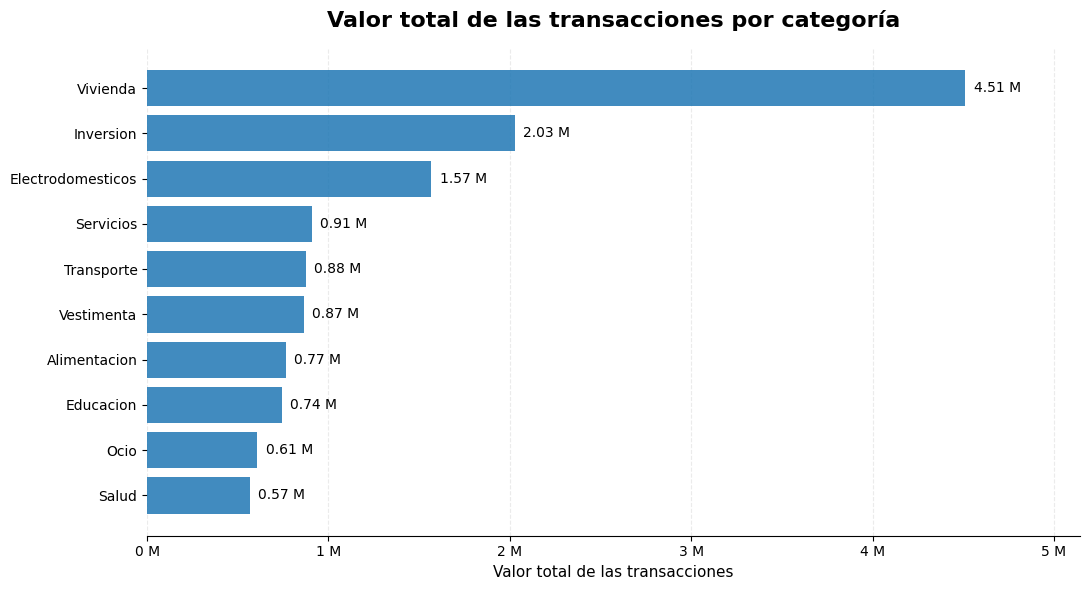

In [34]:
# Ordenar categorías por valor total
datos_grafico = (
    resumen_categorias["Valor_total"]
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 6))

barras = ax.barh(
    datos_grafico.index,
    datos_grafico.values,
    alpha=0.85
)

# Mostrar valor al final de cada barra
for barra in barras:
    valor = barra.get_width()

    ax.text(
        valor + datos_grafico.max() * 0.01,
        barra.get_y() + barra.get_height() / 2,
        f"{valor / 1_000_000:.2f} M",
        va="center",
        fontsize=10
    )

ax.set_title(
    "Valor total de las transacciones por categoría",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Valor total de las transacciones", fontsize=11)
ax.set_ylabel("")

# Formato del eje X en millones
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x / 1_000_000:.0f} M")
)

# Limpiar bordes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

# Espacio para las etiquetas finales
ax.set_xlim(0, datos_grafico.max() * 1.14)

plt.tight_layout()
plt.show()

In [35]:
ticket_categoria = (
    transacciones_eda
    .groupby("categoria")["valor"]
    .agg(
        Media="mean",
        Mediana="median"
    )
    .sort_values("Media", ascending=False)
    .round(2)
)

ticket_categoria

,Media,Mediana
categoria,,
Vivienda,365.78,349.90
Electrodomesticos,334.48,337.58
Inversion,236.57,225.09
Vestimenta,181.85,163.62
Educacion,159.47,150.92
Salud,126.63,112.35
Transporte,104.75,92.10
Ocio,71.09,58.95
Alimentacion,64.25,55.57


**Hallazgos del valor de las transacciones por categoría**

El valor típico de las transacciones presenta diferencias importantes entre categorías. Vivienda registra el mayor valor promedio, con 364.73, seguida de Electrodomésticos (333.08) e Inversión (238.01). En contraste, Servicios (57.06), Alimentación (64.94) y Ocio (71.23) presentan los valores promedio más bajos.

Además, en la mayoría de las categorías la media es superior a la mediana, lo que sugiere la presencia de algunas transacciones de valores elevados que incrementan el promedio. Electrodomésticos constituye una excepción, ya que su mediana (339.09) es ligeramente superior a su media (333.08).


## 8. Análisis temporal de las transacciones


In [36]:
resumen_mensual = (
    transacciones_eda
    .assign(mes=transacciones_eda["fecha"].dt.to_period("M"))
    .groupby("mes")
    .agg(
        Cantidad_transacciones=("id", "count"),
        Valor_total=("valor", "sum"),
        Valor_promedio=("valor", "mean"),
        Valor_mediano=("valor", "median"),
        Usuarios_activos=("usuario_id", "nunique")
    )
)

resumen_mensual.index = resumen_mensual.index.astype(str)

resumen_mensual

,Cantidad_transacciones,Valor_total,Valor_promedio,Valor_mediano,Usuarios_activos
mes,,,,,
2025-01,7237,"1,148,723.11",158.73,92.64,1068
2025-02,6331,"989,765.54",156.34,91.54,1065
2025-03,7136,"1,119,305.48",156.85,92.53,1068
2025-04,6888,"1,113,685.37",161.68,92.61,1068
2025-05,7126,"1,151,357.32",161.57,94.75,1068
2025-06,6977,"1,105,225.51",158.41,92.78,1066
2025-07,7140,"1,138,988.76",159.52,90.54,1069
2025-08,7148,"1,125,341.74",157.43,94.59,1068
2025-09,6919,"1,111,068.57",160.58,94.93,1064


**Hallazgos del comportamiento mensual de las transacciones**

Durante 2025, la actividad transaccional se mantuvo relativamente estable. Marzo registró la mayor cantidad de transacciones, con 3,695, mientras que febrero presentó la menor, con 3,184. En términos de valor total, marzo también alcanzó el mayor monto, con 586,635.64.

El valor promedio por transacción mostró variaciones moderadas durante el año, alcanzando su nivel más alto en septiembre (165.40) y el más bajo en junio (156.44). Por su parte, la cantidad de usuarios activos permaneció estable, alrededor de los 1,000 usuarios mensuales, lo que indica una participación constante a lo largo del período.

In [37]:
resumen_mensual_normalizado = resumen_mensual.copy()

resumen_mensual_normalizado["Dias_mes"] = (
    pd.PeriodIndex(
        resumen_mensual_normalizado.index,
        freq="M"
    ).days_in_month
)

resumen_mensual_normalizado["Transacciones_por_dia"] = (
    resumen_mensual_normalizado["Cantidad_transacciones"]
    / resumen_mensual_normalizado["Dias_mes"]
)

resumen_mensual_normalizado["Valor_por_dia"] = (
    resumen_mensual_normalizado["Valor_total"]
    / resumen_mensual_normalizado["Dias_mes"]
)

resumen_mensual_normalizado[
    [
        "Dias_mes",
        "Transacciones_por_dia",
        "Valor_por_dia"
    ]
].round(2)

,Dias_mes,Transacciones_por_dia,Valor_por_dia
mes,,,
2025-01,31,233.45,"37,055.58"
2025-02,28,226.11,"35,348.77"
2025-03,31,230.19,"36,106.63"
2025-04,30,229.60,"37,122.85"
2025-05,31,229.87,"37,140.56"
2025-06,30,232.57,"36,840.85"
2025-07,31,230.32,"36,741.57"
2025-08,31,230.58,"36,301.35"
2025-09,30,230.63,"37,035.62"


**Hallazgos de la actividad transaccional diaria**

Al ajustar la cantidad de transacciones por el número de días de cada mes, la actividad diaria se mantiene relativamente estable durante 2025. Marzo presenta el mayor promedio, con 119.19 transacciones por día, mientras que mayo registra el menor, con 112.42 transacciones diarias.

En cuanto al valor monetario, septiembre alcanza el mayor valor promedio diario, con 19,197.65, seguido de noviembre con 19,064.20. El menor valor diario se registra en febrero, con 17,866.92.

En general, las diferencias entre meses son moderadas, por lo que no se observa una variación temporal pronunciada en la actividad transaccional durante el año.

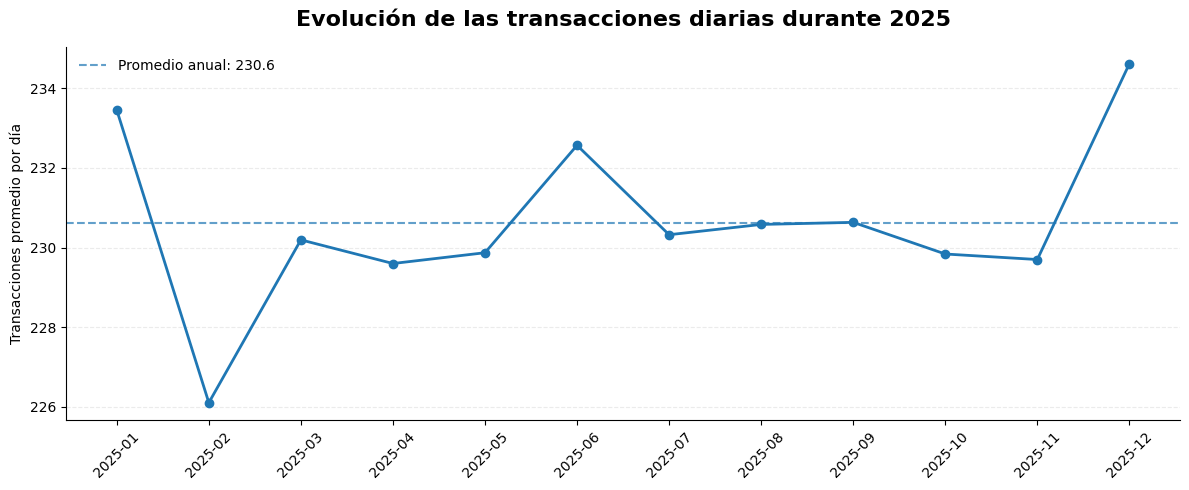

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))

meses = resumen_mensual_normalizado.index
valores = resumen_mensual_normalizado["Transacciones_por_dia"]

ax.plot(
    meses,
    valores,
    marker="o",
    linewidth=2
)

# Promedio anual
promedio = valores.mean()

ax.axhline(
    promedio,
    linestyle="--",
    alpha=0.7,
    label=f"Promedio anual: {promedio:.1f}"
)

ax.set_title(
    "Evolución de las transacciones diarias durante 2025",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Transacciones promedio por día")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.legend(frameon=False)
ax.set_axisbelow(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Análisis agregado por usuario


In [39]:
metricas_usuario = (
    transacciones_eda
    .groupby("usuario_id")
    .agg(
        cantidad_transacciones=("id", "count"),
        valor_total=("valor", "sum"),
        valor_promedio=("valor", "mean"),
        valor_mediano=("valor", "median"),
        valor_maximo=("valor", "max"),
        categorias_utilizadas=("categoria", "nunique"),
        dias_activos=("fecha", "nunique")
    )
    .reset_index()
)

metricas_usuario.head()

,usuario_id,cantidad_transacciones,valor_total,valor_promedio,valor_mediano,valor_maximo,categorias_utilizadas,dias_activos
0,1,78,"10,951.79",140.41,80.81,524.22,10,69
1,2,73,"15,203.00",208.26,129.20,704.66,10,66
2,5,74,"10,504.22",141.95,78.75,483.40,10,67
3,8,73,"12,454.38",170.61,104.51,533.41,10,64
4,12,81,"17,217.19",212.56,112.82,810.80,10,74


In [40]:
pd.DataFrame({
    "Métrica": [
        "Usuarios originales",
        "Usuarios con transacciones_eda",
        "Usuarios sin transacciones_eda"
    ],
    "Resultado": [
        usuarios_eda["id"].nunique(),
        metricas_usuario["usuario_id"].nunique(),
        usuarios_eda["id"].nunique() - metricas_usuario["usuario_id"].nunique()
    ]
})

,Métrica,Resultado
0,Usuarios originales,1069
1,Usuarios con transacciones_eda,1069
2,Usuarios sin transacciones_eda,0


### 9.1 Integración de información financiera y transaccional


In [41]:
usuarios_completo = usuarios_eda.merge(
    metricas_usuario,
    left_on="id",
    right_on="usuario_id",
    how="left",
    validate="one_to_one"
)

usuarios_completo.head()

,id,nombre,ingreso_mensual,nivel_endeudamiento,frecuencia_ahorro,perfil_financiero,split,usuario_id,cantidad_transacciones,valor_total,valor_promedio,valor_mediano,valor_maximo,categorias_utilizadas,dias_activos
0,1,Feliciana,"2,353.28",16.27,Media,Saludable,train,1,78,"10,951.79",140.41,80.81,524.22,10,69
1,2,Dani,"4,257.03",13.38,Media,Saludable,train,2,73,"15,203.00",208.26,129.20,704.66,10,66
2,5,Leonardo,"1,925.49",19.06,Baja,En observacion,train,5,74,"10,504.22",141.95,78.75,483.40,10,67
3,8,Emilio,"3,775.73",14.04,Media,Saludable,train,8,73,"12,454.38",170.61,104.51,533.41,10,64
4,12,Manu,"4,419.47",12.56,Baja,En observacion,train,12,81,"17,217.19",212.56,112.82,810.80,10,74


In [42]:
verificacion_merge = pd.DataFrame({
    "Métrica": [
        "Filas antes del merge",
        "Filas después del merge",
        "Usuarios únicos",
        "Duplicados por ID",
        "Usuarios sin métricas transaccionales"
    ],
    "Resultado": [
        len(usuarios_eda),
        len(usuarios_completo),
        usuarios_completo["id"].nunique(),
        usuarios_completo["id"].duplicated().sum(),
        usuarios_completo["cantidad_transacciones"].isna().sum()
    ]
})

verificacion_merge

,Métrica,Resultado
0,Filas antes del merge,1069
1,Filas después del merge,1069
2,Usuarios únicos,1069
3,Duplicados por ID,0
4,Usuarios sin métricas transaccionales,0


In [43]:
pd.DataFrame({
    "Métrica": [
        "Mínimo de categorías utilizadas",
        "Máximo de categorías utilizadas",
        "Promedio de categorías utilizadas"
    ],
    "Resultado": [
        usuarios_completo["categorias_utilizadas"].min(),
        usuarios_completo["categorias_utilizadas"].max(),
        usuarios_completo["categorias_utilizadas"].mean()
    ]
})

,Métrica,Resultado
0,Mínimo de categorías utilizadas,8.00
1,Máximo de categorías utilizadas,10.00
2,Promedio de categorías utilizadas,9.95


### 9.2 Comportamiento transaccional según perfil financiero


In [44]:
resumen_transaccional_perfil = (
    usuarios_completo
    .groupby("perfil_financiero")
    .agg(
        Usuarios=("id", "count"),
        Transacciones_promedio=("cantidad_transacciones", "mean"),
        Valor_total_promedio=("valor_total", "mean"),
        Ticket_promedio=("valor_promedio", "mean"),
        Ticket_mediano=("valor_mediano", "mean"),
        Valor_maximo_promedio=("valor_maximo", "mean"),
        Dias_activos_promedio=("dias_activos", "mean")
    )
    .round(2)
)

resumen_transaccional_perfil

,Usuarios,Transacciones_promedio,Valor_total_promedio,Ticket_promedio,Ticket_mediano,Valor_maximo_promedio,Dias_activos_promedio
perfil_financiero,,,,,,,
En observacion,324,77.08,"12,859.80",166.49,95.67,625.34,69.27
En riesgo,109,78.57,"15,295.09",194.76,106.97,880.67,70.00
Saludable,636,79.65,"11,967.13",150.41,95.17,530.18,71.49


**Hallazgos del comportamiento transaccional según perfil financiero**

El análisis muestra diferencias en el comportamiento transaccional entre los perfiles financieros. Los usuarios saludables presentan ligeramente más transacciones en promedio (40.07) y mayor cantidad de días activos (37.98), aunque registran el menor gasto total promedio (6,051.48) y el menor ticket promedio (151.17).

Los usuarios en riesgo, por el contrario, realizan un número similar de transacciones (39.63), pero presentan el mayor gasto total promedio (7,734.81), el ticket promedio más alto (195.67) y un valor máximo promedio de 820.62, considerablemente superior al de los demás perfiles.

Estos resultados sugieren que las diferencias entre perfiles no se explican principalmente por la cantidad de transacciones realizadas, sino por el valor monetario de esas transacciones, siendo los usuarios en riesgo quienes presentan un mayor nivel de gasto por operación.

### 9.3 Composición del gasto por categoría y perfil financiero


In [45]:
gasto_usuario_categoria = (
    transacciones_eda
    .groupby(["usuario_id", "categoria"])["valor"]
    .sum()
    .reset_index()
)

gasto_usuario_categoria = gasto_usuario_categoria.merge(
    usuarios_eda[["id", "perfil_financiero"]],
    left_on="usuario_id",
    right_on="id",
    how="left"
)

resumen_gasto_categoria_perfil = (
    gasto_usuario_categoria
    .groupby(["perfil_financiero", "categoria"])["valor"]
    .mean()
    .unstack()
    .round(2)
)

resumen_gasto_categoria_perfil

categoria,Alimentacion,Educacion,Electrodomesticos,Inversion,Ocio,Salud,Servicios,Transporte,Vestimenta,Vivienda
perfil_financiero,,,,,,,,,,
En observacion,758.31,707.86,"1,570.04","1,423.43",579.47,541.38,924.55,851.78,848.51,"4,713.10"
En riesgo,665.88,680.54,"1,263.10","1,637.78",597.76,510.43,"1,373.85",749.25,997.73,"6,841.96"
Saludable,706.02,707.39,"1,481.01","2,179.75",557.95,537.81,724.45,817.36,774.49,"3,520.06"


**Hallazgos del gasto por categoría según perfil financiero**

Se observan diferencias relevantes en la distribución del gasto según el perfil financiero. Vivienda representa el mayor gasto promedio en los tres perfiles, pero alcanza su valor más alto entre los usuarios en riesgo, con 3,480.48, frente a 2,397.52 en los usuarios en observación y 1,767.78 en los saludables.

Por otro lado, los usuarios saludables presentan un mayor gasto promedio en Inversión (1,108.61) que los usuarios en observación (752.22) y en riesgo (890.88). Esto marca una diferencia interesante en la composición del gasto entre los perfiles.

En conjunto, los resultados muestran que los usuarios en riesgo concentran una mayor cantidad de recursos en Vivienda, mientras que los usuarios saludables destinan comparativamente más recursos a Inversión. Estas diferencias ayudan a comprender qué categorías están asociadas con los distintos comportamientos financieros observados.

In [46]:
distribucion_gasto_perfil = (
    resumen_gasto_categoria_perfil
    .div(resumen_gasto_categoria_perfil.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

distribucion_gasto_perfil

categoria,Alimentacion,Educacion,Electrodomesticos,Inversion,Ocio,Salud,Servicios,Transporte,Vestimenta,Vivienda
perfil_financiero,,,,,,,,,,
En observacion,5.87,5.48,12.15,11.02,4.49,4.19,7.16,6.59,6.57,36.48
En riesgo,4.35,4.44,8.25,10.69,3.90,3.33,8.97,4.89,6.51,44.67
Saludable,5.88,5.89,12.34,18.16,4.65,4.48,6.03,6.81,6.45,29.32


**Hallazgos de la distribución porcentual del gasto**

La distribución del gasto muestra diferencias claras entre los perfiles financieros. Los usuarios en riesgo concentran el 43.67% de su gasto en Vivienda, siendo la proporción más alta entre los tres perfiles. En comparación, Vivienda representa el 35.39% del gasto de los usuarios en observación y el 28.07% de los saludables.

Los usuarios saludables destinan una mayor proporción a Inversión (17.61%), frente al 11.10% de los usuarios en observación y el 11.18% de los usuarios en riesgo. También presentan una participación relativamente mayor en Electrodomésticos (13.28%).

Estos resultados sugieren que la composición del gasto, y no solamente el monto total gastado, permite identificar diferencias importantes entre los perfiles financieros

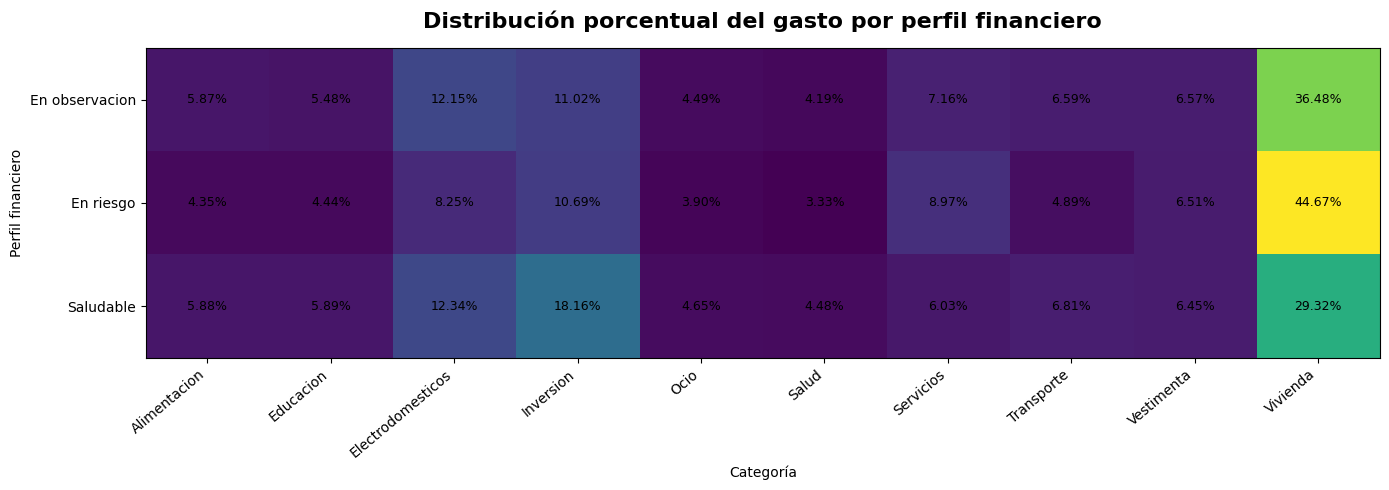

In [47]:
import matplotlib.pyplot as plt
import numpy as np

datos = distribucion_gasto_perfil.copy()

fig, ax = plt.subplots(figsize=(14, 5))

im = ax.imshow(datos.values, aspect="auto")

ax.set_xticks(np.arange(len(datos.columns)))
ax.set_xticklabels(datos.columns, rotation=40, ha="right")

ax.set_yticks(np.arange(len(datos.index)))
ax.set_yticklabels(datos.index)

# Mostrar porcentajes dentro de cada celda
for i in range(len(datos.index)):
    for j in range(len(datos.columns)):
        ax.text(
            j, i,
            f"{datos.iloc[i, j]:.2f}%",
            ha="center",
            va="center",
            fontsize=9
        )

ax.set_title(
    "Distribución porcentual del gasto por perfil financiero",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Categoría")
ax.set_ylabel("Perfil financiero")

plt.tight_layout()
plt.show()

### 9.4 Relación entre gasto e ingreso

Se analiza el nivel de gasto de los usuarios en relación con sus ingresos. Para mantener la comparabilidad temporal, el ingreso mensual se transforma en ingreso anual estimado antes de calcular la proporción destinada a transacciones.


In [48]:
# Ingreso anual estimado
usuarios_completo["ingreso_anual_estimado"] = (
    usuarios_completo["ingreso_mensual"] * 12
)

# Porcentaje del ingreso anual representado por las transacciones_eda
usuarios_completo["porcentaje_ingreso_gastado"] = (
    usuarios_completo["valor_total"] /
    usuarios_completo["ingreso_anual_estimado"] * 100
)

# Resumen según perfil financiero
resumen_gasto_ingreso = (
    usuarios_completo
    .groupby("perfil_financiero")
    .agg(
        Usuarios=("id", "count"),
        Ingreso_mensual_promedio=("ingreso_mensual", "mean"),
        Ingreso_anual_estimado_promedio=("ingreso_anual_estimado", "mean"),
        Gasto_anual_promedio=("valor_total", "mean"),
        Porcentaje_ingreso_gastado_promedio=("porcentaje_ingreso_gastado", "mean"),
        Porcentaje_ingreso_gastado_mediano=("porcentaje_ingreso_gastado", "median")
    )
    .round(2)
)

resumen_gasto_ingreso

,Usuarios,Ingreso_mensual_promedio,Ingreso_anual_estimado_promedio,Gasto_anual_promedio,Porcentaje_ingreso_gastado_promedio,Porcentaje_ingreso_gastado_mediano
perfil_financiero,,,,,,
En observacion,324,"2,845.34","34,144.10","12,859.80",38.77,37.79
En riesgo,109,"2,326.86","27,922.33","15,295.09",55.73,54.31
Saludable,636,"2,801.41","33,616.96","11,967.13",37.08,37.13


**Hallazgos sobre la relación entre ingresos y gastos**

Los resultados muestran diferencias importantes en la proporción del ingreso destinada al gasto según el perfil financiero. Los usuarios en riesgo presentan el mayor porcentaje promedio de ingreso gastado, con **28.21%**, mientras que los usuarios en observación registran **19.43%** y los saludables **18.72%**.

Además, el perfil en riesgo presenta el menor ingreso mensual promedio (**2,326.86**), pero un gasto anual promedio de **7,734.81**, superior al observado en los perfiles saludable (**6,051.48**) y en observación (**6,461.63**).

Esto evidencia que los usuarios clasificados como en riesgo tienen una mayor presión del gasto sobre sus ingresos, lo que resulta coherente con su situación financiera.


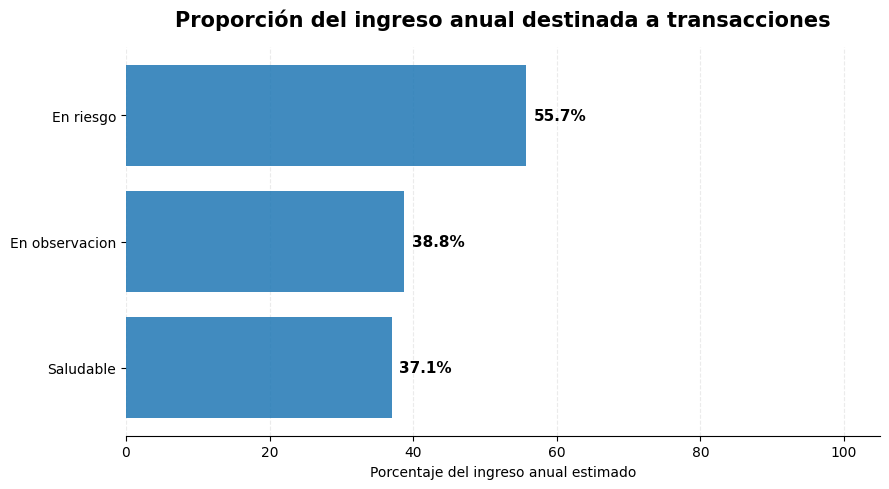

In [49]:
datos = (
    resumen_gasto_ingreso["Porcentaje_ingreso_gastado_promedio"]
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.barh(
    datos.index,
    datos.values,
    alpha=0.85
)

for barra in barras:
    valor = barra.get_width()

    ax.text(
        valor + 1,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1f}%",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Proporción del ingreso anual destinada a transacciones",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Porcentaje del ingreso anual estimado")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

ax.set_xlim(0, 105)

plt.tight_layout()
plt.show()

### 9.5 Correlación entre variables financieras y transaccionales

Se analiza la relación entre las principales variables numéricas a nivel de usuario para identificar asociaciones entre ingresos, endeudamiento y comportamiento transaccional.


In [50]:
# Variables numéricas relevantes para el análisis
variables_correlacion = [
    "ingreso_mensual",
    "nivel_endeudamiento",
    "cantidad_transacciones",
    "valor_total",
    "valor_promedio",
    "valor_mediano",
    "valor_maximo",
    "dias_activos",
    "porcentaje_ingreso_gastado"
]

# Matriz de correlación
matriz_correlacion = (
    usuarios_completo[variables_correlacion]
    .corr()
    .round(2)
)

matriz_correlacion

,ingreso_mensual,nivel_endeudamiento,cantidad_transacciones,valor_total,valor_promedio,valor_mediano,valor_maximo,dias_activos,porcentaje_ingreso_gastado
ingreso_mensual,1.00,-0.34,-0.03,0.52,0.58,0.47,0.48,-0.02,-0.54
nivel_endeudamiento,-0.34,1.00,-0.01,0.40,0.43,0.14,0.52,-0.03,0.77
cantidad_transacciones,-0.03,-0.01,1.00,0.39,-0.03,-0.05,0.04,0.94,0.41
valor_total,0.52,0.40,0.39,1.00,0.90,0.66,0.78,0.35,0.41
valor_promedio,0.58,0.43,-0.03,0.90,1.00,0.74,0.84,-0.04,0.25
valor_mediano,0.47,0.14,-0.05,0.66,0.74,1.00,0.49,-0.05,0.15
valor_maximo,0.48,0.52,0.04,0.78,0.84,0.49,1.00,0.02,0.24
dias_activos,-0.02,-0.03,0.94,0.35,-0.04,-0.05,0.02,1.00,0.36
porcentaje_ingreso_gastado,-0.54,0.77,0.41,0.41,0.25,0.15,0.24,0.36,1.00


#### Matriz de correlación


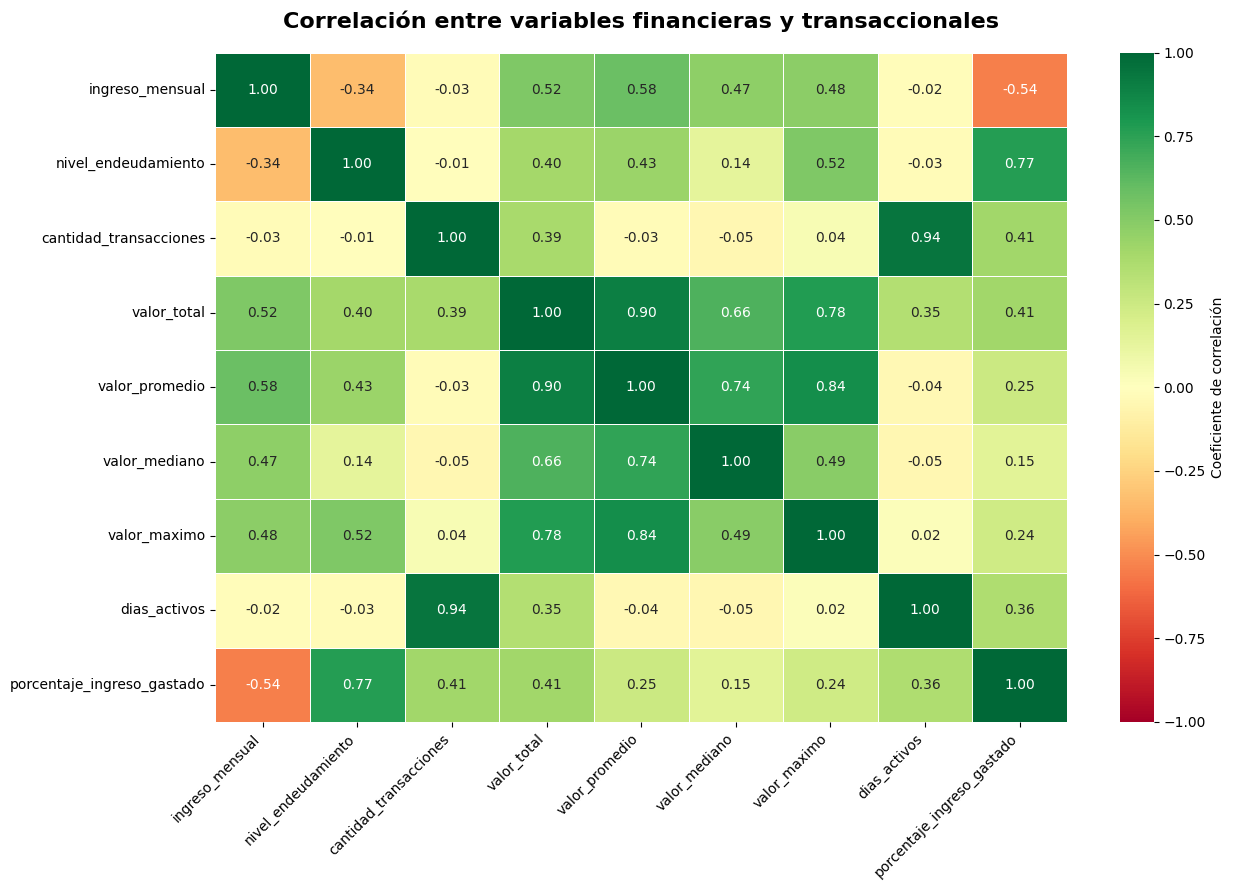

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(13, 9))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "Coeficiente de correlación"}
)

plt.title(
    "Correlación entre variables financieras y transaccionales",
    fontsize=16,
    fontweight="bold",
    pad=18
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Hallazgos del análisis de correlación**

La matriz de correlación permite identificar las principales relaciones entre las variables financieras y transaccionales. Se observa una correlación positiva fuerte entre el nivel de endeudamiento y el porcentaje del ingreso gastado (**0.67**), indicando que un mayor endeudamiento tiende a estar asociado con una mayor proporción del ingreso destinada al gasto.

También destaca la relación entre cantidad de transacciones y días activos (**0.97**), así como entre valor total y valor promedio de las transacciones (**0.85**) y entre valor promedio y valor máximo (**0.82**).

Por otro lado, el ingreso mensual presenta una correlación negativa moderada con el porcentaje del ingreso gastado (**-0.45**) y con el nivel de endeudamiento (**-0.34**). Esto sugiere que, dentro del conjunto analizado, los usuarios con mayores ingresos tienden a destinar una menor proporción de sus ingresos al gasto y a presentar menores niveles de endeudamiento.


# 10. Principales hallazgos y conclusión del EDA

Esta sección sintetiza los patrones más relevantes identificados durante el análisis exploratorio de datos, utilizando los usuarios pertenecientes al conjunto `train` y conservando el historial completo de transacciones de dichos usuarios.

---

## Principales hallazgos

### 1. Predominio del perfil saludable

De los usuarios analizados, **636 (59.49%)** pertenecen al perfil **Saludable**, **324 (30.31%)** se encuentran **En observación** y **109 (10.20%)** están clasificados **En riesgo**.

Esto indica que la mayoría de los usuarios presenta una situación financiera favorable, aunque existe un grupo relevante que requiere observación y una proporción menor que presenta condiciones de mayor riesgo financiero.

### 2. El perfil en riesgo combina menores ingresos con mayor gasto

Los usuarios clasificados **En riesgo** presentan el menor ingreso mensual promedio (**2,326.86**), pero registran el mayor gasto promedio (**7,734.81**).

En comparación, los usuarios **Saludables** presentan un ingreso mensual promedio de **2,801.41** y un gasto promedio de **6,051.48**, mientras que los usuarios **En observación** registran un ingreso promedio de **2,845.34** y un gasto de **6,461.63**.

Este comportamiento muestra que un mayor ingreso no necesariamente está asociado con una peor situación financiera.

### 3. Mayor presión del gasto en los usuarios en riesgo

Los usuarios **En riesgo** destinan en promedio el **28.21% de sus ingresos al gasto**, porcentaje superior al **19.43%** registrado por los usuarios **En observación** y al **18.72%** correspondiente a los usuarios **Saludables**.

Esto evidencia una mayor presión del gasto sobre los recursos disponibles en el grupo de mayor riesgo financiero.

### 4. Vivienda concentra una parte importante del gasto

La categoría **Vivienda** representa el **43.67%** del gasto de los usuarios **En riesgo**, frente al **35.39%** de los usuarios **En observación** y el **28.07%** de los usuarios **Saludables**.

Por lo tanto, los usuarios en riesgo presentan una mayor concentración de sus gastos en vivienda.

### 5. La inversión tiene mayor peso entre los usuarios saludables

Los usuarios **Saludables** destinan aproximadamente el **17.61%** de sus gastos a la categoría **Inversión**.

Esta proporción es superior a la observada en los usuarios **En observación (11.10%)** y **En riesgo (11.18%)**.

Este patrón constituye una de las diferencias más relevantes encontradas en la composición del gasto entre los perfiles financieros.

### 6. Los usuarios en riesgo realizan operaciones de mayor valor

El perfil **En riesgo** presenta el ticket promedio más elevado, con un valor de **195.67**, frente a **166.83** en los usuarios **En observación** y **151.17** en los usuarios **Saludables**.

Asimismo, los usuarios en riesgo presentan el mayor valor máximo promedio de transacción (**820.62**), lo que evidencia operaciones individuales de mayor magnitud dentro de este grupo.

### 7. La cantidad de categorías utilizadas aporta poca diferenciación

Los usuarios utilizan en promedio **9.46 de las 10 categorías disponibles**, con un mínimo de **6** y un máximo de **10** categorías por usuario.

Debido a esta alta cobertura de categorías, la cantidad de categorías utilizadas por sí sola parece aportar poca capacidad para diferenciar los perfiles financieros.

### 8. Las correlaciones respaldan los patrones financieros encontrados

El **nivel de endeudamiento** presenta una correlación positiva de **0.67** con el **porcentaje del ingreso gastado**.

Por otro lado, el **ingreso mensual** presenta una correlación negativa de **-0.45** con el porcentaje del ingreso gastado y de **-0.34** con el nivel de endeudamiento.

Estos resultados indican que, dentro del conjunto analizado, un mayor nivel de endeudamiento tiende a estar relacionado con una mayor proporción del ingreso destinada al gasto.

### 9. La actividad transaccional está fuertemente relacionada con los días activos

La **cantidad de transacciones** y los **días activos** presentan una correlación de **0.97**, siendo una de las relaciones más fuertes encontradas durante el análisis.

Esto indica que los usuarios que permanecen activos durante una mayor cantidad de días también tienden a realizar un mayor número de transacciones.

### 10. El comportamiento transaccional mensual es relativamente estable

El análisis temporal de las transacciones durante **2025** muestra un comportamiento relativamente estable entre los diferentes meses.

Aunque existen pequeñas variaciones mensuales, no se identifican cambios extremos en la actividad transaccional durante el período analizado.

---

## Conclusión del EDA

El análisis exploratorio permitió identificar que el **riesgo financiero no depende exclusivamente del nivel de ingresos**, sino también de la manera en que los usuarios distribuyen y utilizan sus recursos.

Los usuarios clasificados **En riesgo** combinan menores ingresos con un mayor gasto promedio, tickets de transacción más elevados, una mayor proporción del ingreso destinada al gasto y una fuerte concentración del gasto en vivienda.

En contraste, los usuarios **Saludables** presentan una menor presión del gasto sobre sus ingresos y una mayor participación de la inversión dentro de su estructura de gastos.

Las correlaciones encontradas también muestran que variables como el **nivel de endeudamiento**, el **porcentaje del ingreso gastado**, el **ingreso mensual** y diferentes características del comportamiento transaccional contienen información relevante para caracterizar la situación financiera de los usuarios.

En conjunto, estos resultados permiten comprender mejor los patrones presentes en los datos y proporcionan una base sólida para las etapas posteriores del proyecto, incluyendo la selección de variables y el desarrollo de modelos analíticos o predictivos.

---

## Nota metodológica

Para evitar **fugas de información (data leakage)**, el EDA se realizó tomando como referencia exclusivamente el `split = train` de la **tabla de usuarios**.

El campo `split` de la **tabla de transacciones no se utilizó como criterio de filtrado**, debido a que corresponde al particionado temporal destinado al entrenamiento y validación del modelo NLP de clasificación de textos.

De esta manera, se conserva el **historial completo de transacciones de cada usuario perteneciente al conjunto `train`**, manteniendo toda la información de cada individuo dentro del mismo grupo.
